# Benchmark ASR Wav2Vec2 (`nguyenvulebinh/wav2vec2-base-vietnamese-250h`) & Two-Stage Pipeline

Notebook này được xây dựng theo yêu cầu để kiểm thử toàn diện độ chính xác **WER (Word Error Rate)**, **CER (Character Error Rate)**, và **Tốc độ suy luận (RTF)** trên 100% dữ liệu y tế mới.

Đặc biệt, notebook triển khai và so sánh **ĐÚNG 3 CHẾ ĐỘ GIẢI MÃ (Decoding Modes)**:
1. **Greedy Decoding (Argmax gốc của Wav2Vec2)**: Nhận dạng thô dựa trên xác suất âm học max tại từng khung hình.
2. **Beam Search + Hotwords (Không có KenLM & Không có ViT5)**: Sử dụng `pyctcdecode` ép bắt danh mục từ khóa biệt dược (`drugs.txt` / $Weight=15.0$).
3. **Two-Stage Pipeline (Beam Search + KenLM + Hotwords -> ViT5 Rewrite)**: Tích hợp đầy đủ mô hình ngôn ngữ 4-gram `kenlm_vi_medical_4gram.bin` ở Tầng 1 và dịch chuẩn hóa lỗi ASR sang câu hỏi y tế hoàn hảo bằng `vit5_medical_rewrite_final` ở Tầng 2.

In [1]:
# 0. Cài đặt ổn định các gói cần thiết cho Wav2Vec2, pyctcdecode, KenLM và ViT5
!pip install -q -U "transformers<4.40.0" "tokenizers<0.19.0" "accelerate<0.29.0" "peft==0.10.0" protobuf sentencepiece
!pip install -q --no-deps pyctcdecode kenlm jiwer pygtrie hypothesis rapidfuzz click

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.1/199.1 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 88.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.1/290.1 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 31.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
grpcio-tools 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.35.

In [2]:
import os
import time
import warnings
import torch
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import jiwer
from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor
from pyctcdecode import build_ctcdecoder

warnings.filterwarnings('ignore')

# Thiết lập thiết bị GPU/CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("=" * 60)
print(f"Sử dụng thiết bị (Device): {device}")
if torch.cuda.is_available():
    print(f"Tên GPU: {torch.cuda.get_device_name(0)}")
print("=" * 60)

Sử dụng thiết bị (Device): cuda
Tên GPU: Tesla T4


## 1. Cấu hình Đường dẫn Dữ liệu & Mô hình

Vui lòng dán chính xác đường dẫn đến các file và thư mục cần thiết trong cell cấu hình bên dưới:
- **`CSV_PATH`**: Đường dẫn tới file `train.csv`.
- **`WAVS_DIR`**: Thư mục chứa các file âm thanh `.wav`.
- **`DRUGS_PATH`**: File từ khóa biệt dược `drugs.txt` (dùng làm Hotwords cho `pyctcdecode`).
- **`KENLM_PATH`**: File mô hình ngôn ngữ `kenlm_vi_medical_4gram.bin`.
- **`VIT5_PATH`**: Thư mục checkpoint `vit5_medical_rewrite_final` sau khi fine-tune.

In [3]:
# ==============================================================================
# VUI LÒNG ĐIỀN CHÍNH XÁC ĐƯỜNG DẪN CÁC FILE VÀ THƯ MỤC TRÊN KAGGLE TẠI ĐÂY:
# ==============================================================================
CSV_PATH   = "/kaggle/input/datasets/hdtuznn/voice-medical/train_set/train.csv"
WAVS_DIR   = "/kaggle/input/datasets/hdtuznn/voice-medical/train_set/wavs"
DRUGS_PATH = "/kaggle/input/datasets/hdtuznn/sppr-text/data/text/drugs.txt"
KENLM_PATH = "/kaggle/input/models/hdtuznn/kenlm/pytorch/default/1/kenlm_vi_medical_4gram.bin"
VIT5_PATH  = "/kaggle/input/models/hdtuznn/vit5-medical-rewrite-final/pytorch/default/3/vit5_medical_rewrite_final"

HOTWORD_WEIGHT = 15.0
# ==============================================================================

# Đọc toàn bộ dữ liệu mẫu test/benchmark
df_train = pd.read_csv(CSV_PATH)
print(f"\nTổng số mẫu trong dataset: {len(df_train)} mẫu audio y tế")

# Ánh xạ chính xác đường dẫn file audio tới thư mục wavs thực tế
def get_audio_path(row_path):
    filename = Path(row_path).name
    audio_full_path = Path(WAVS_DIR) / filename
    if not audio_full_path.exists():
        alt_path = Path(CSV_PATH).parent / Path(row_path)
        if alt_path.exists():
            return alt_path.as_posix()
    return audio_full_path.as_posix()

df_train['audio_path'] = df_train['path'].apply(get_audio_path)


Tổng số mẫu trong dataset: 120 mẫu audio y tế


## 2. Khởi tạo Mô hình Wav2Vec2, KenLM, Hotwords & ViT5 Rewrite

Khởi tạo mô hình acoustic `nguyenvulebinh/wav2vec2-base-vietnamese-250h`, cấu hình 2 bộ giải mã `pyctcdecode`:
- `decoder_no_lm`: Beam Search (không nạp KenLM) để chạy với Hotwords cho Chế độ 2.
- `decoder_kenlm`: Beam Search tích hợp `kenlm_vi_medical_4gram.bin` để chạy cho Chế độ 3.

Đồng thời nạp mô hình `AutoModelForSeq2SeqLM` (`vit5_medical_rewrite_final`) để chuẩn hóa Tầng 2.

In [4]:
# Khởi tạo thiết bị
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Đang sử dụng thiết bị suy luận: {device.upper()}")

# ------------------------------------------------------------------------------
# 1. TẢI MÔ HÌNH ACOUSTIC WAV2VEC2
# ------------------------------------------------------------------------------
from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor, AutoTokenizer, AutoModelForSeq2SeqLM
from pyctcdecode import build_ctcdecoder

MODEL_ID = "nguyenvulebinh/wav2vec2-base-vietnamese-250h"
print(f"Đang tải mô hình ASR: {MODEL_ID}...")

try:
    processor = Wav2Vec2Processor.from_pretrained(MODEL_ID)
except TypeError:
    processor = Wav2Vec2Processor.from_pretrained(
        MODEL_ID,
        additional_special_tokens=["<s>", "</s>"],
        extra_special_tokens={}
    )

model = Wav2Vec2ForCTC.from_pretrained(MODEL_ID).to(device)
model.eval()

# Xây dựng danh sách ký tự (vocab) chuẩn hóa cho pyctcdecode
vocab_dict = processor.tokenizer.get_vocab()
sorted_vocab = sorted((value, key) for (key, value) in vocab_dict.items())
vocab_list = [key for (value, key) in sorted_vocab]
vocab_list[vocab_dict["|"]] = " "

# Cắt đúng model.config.vocab_size token đầu tiên để khớp channels output
model_vocab_size = model.config.vocab_size
vocab_list = vocab_list[:model_vocab_size]
print(f"Model vocab_size: {model_vocab_size}, pyctc_vocab length: {len(vocab_list)}")

# ------------------------------------------------------------------------------
# 2. ĐỌC DANH SÁCH HOTWORDS TỪ FILE DRUGS.TXT
# ------------------------------------------------------------------------------
print(f"\nĐang nạp danh sách từ khóa thuốc từ: {DRUGS_PATH}...")
HOTWORDS_MEDICAL = [line.strip() for line in open(DRUGS_PATH, "r", encoding="utf-8") if line.strip()]
print(f"Đã nạp {len(HOTWORDS_MEDICAL):,} từ khóa biệt dược vào Hotwords (Weight = {HOTWORD_WEIGHT})!")

# ------------------------------------------------------------------------------
# 3. KHỞI TẠO BỘ GIẢI MÃ PYCTCDECODE (KHÔNG KENLM & CÓ KENLM)
# ------------------------------------------------------------------------------
print(f"Đang cấu hình CTC Beam Search Decoder với KenLM tại: {KENLM_PATH}...")
decoder_no_lm = build_ctcdecoder(labels=vocab_list, kenlm_model_path=None)
decoder_kenlm = build_ctcdecoder(labels=vocab_list, kenlm_model_path=KENLM_PATH)

# ------------------------------------------------------------------------------
# 4. TẢI MÔ HÌNH VIT5 MEDICAL REWRITE CHO TẦNG 2
# ------------------------------------------------------------------------------
print(f"\nĐang tải mô hình ViT5 Rewrite từ: {VIT5_PATH}...")
vit5_tokenizer = AutoTokenizer.from_pretrained(VIT5_PATH)
vit5_model = AutoModelForSeq2SeqLM.from_pretrained(VIT5_PATH).to(device)
vit5_model.tie_weights()
vit5_model.eval()
print("Hoàn tất khởi tạo toàn bộ pipeline 3 chế độ chuẩn xác 100%!")

Đang sử dụng thiết bị suy luận: CUDA
Đang tải mô hình ASR: nguyenvulebinh/wav2vec2-base-vietnamese-250h...


preprocessor_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Some weights of the model checkpoint at nguyenvulebinh/wav2vec2-base-vietnamese-250h were not used when initializing Wav2Vec2ForCTC: ['wav2vec2.encoder.pos_conv_embed.conv.weight_g', 'wav2vec2.encoder.pos_conv_embed.conv.weight_v']
- This IS expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at nguyenvulebinh/wav2vec2-base-vietnamese-250h and are newly initialized: ['wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You

Model vocab_size: 110, pyctc_vocab length: 110

Đang nạp danh sách từ khóa thuốc từ: /kaggle/input/datasets/hdtuznn/sppr-text/data/text/drugs.txt...
Đã nạp 6,069 từ khóa biệt dược vào Hotwords (Weight = 15.0)!
Đang cấu hình CTC Beam Search Decoder với KenLM tại: /kaggle/input/models/hdtuznn/kenlm/pytorch/default/1/kenlm_vi_medical_4gram.bin...


Unigrams not provided and cannot be automatically determined from LM file (only arpa format). Decoding accuracy might be reduced.
No known unigrams provided, decoding results might be a lot worse.



Đang tải mô hình ViT5 Rewrite từ: /kaggle/input/models/hdtuznn/vit5-medical-rewrite-final/pytorch/default/3/vit5_medical_rewrite_final...
Hoàn tất khởi tạo toàn bộ pipeline 3 chế độ chuẩn xác 100%!


## 3. Benchmark 100% Dữ Liệu: Đo lường WER, CER & Tốc Độ cho 3 Chế Độ

Tiến hành suy luận trên toàn bộ dataset cho đúng 3 chế độ được chọn:
1. **Greedy Decoding (Argmax)**
2. **Beam Search + Hotwords** (Không KenLM, Không ViT5)
3. **Two-Stage Pipeline** (Beam Search + KenLM + Hotwords -> ViT5 Rewrite)

In [5]:
def calculate_metrics(ref, hyp):
    # Chuẩn hóa về chữ thường và cắt khoảng trắng thừa trước khi chấm điểm
    ref_norm = jiwer.ToLowerCase()(str(ref).strip())
    hyp_norm = jiwer.ToLowerCase()(str(hyp).strip())
    if not ref_norm:
        return 0.0, 0.0
    wer = jiwer.wer(ref_norm, hyp_norm)
    cer = jiwer.cer(ref_norm, hyp_norm)
    return wer, cer

detailed_logs = []
print(f"Bắt đầu chạy benchmark trên toàn bộ {len(df_train)} mẫu âm thanh y tế...\n")

total_audio_duration = 0.0
total_time_greedy = 0.0
total_time_beam_hw = 0.0
total_time_two_stage = 0.0

# Tối ưu hóa siêu tốc cho Beam Search
BEAM_WIDTH = 16
BEAM_PRUNE_LOGP = -5.0
TOKEN_MIN_LOGP = -3.0

for idx, row in tqdm(df_train.iterrows(), total=len(df_train), desc="Benchmarking 3 Modes"):
    audio_path = row['audio_path']
    ref_text = str(row['text']) if pd.notnull(row['text']) else ""
    
    if not os.path.exists(audio_path):
        continue
        
    speech, sr = librosa.load(audio_path, sr=16000)
    audio_duration = len(speech) / sr
    total_audio_duration += audio_duration
    
    inputs = processor(speech, sampling_rate=16000, return_tensors="pt", padding=True)
    input_values = inputs.input_values.to(device)
    
    # --- FEATURE EXTRACTION (WAV2VEC2 LOGITS) ---
    start_t = time.time()
    with torch.no_grad():
        logits = model(input_values).logits[0]
    model_time = time.time() - start_t
    
    # --------------------------------------------------------------------------
    # MODE 1: Greedy Decoding (Argmax)
    # --------------------------------------------------------------------------
    start_t_greedy = time.time()
    pred_ids = torch.argmax(logits, dim=-1)
    trans_greedy = processor.decode(pred_ids).lower()
    total_time_greedy += (model_time + (time.time() - start_t_greedy))
    
    # --------------------------------------------------------------------------
    # MODE 2: Beam Search + Hotwords (Thường - Không KenLM & Không ViT5)
    # --------------------------------------------------------------------------
    start_t_beam_hw = time.time()
    logits_np = logits.cpu().numpy()
    trans_beam_hw = decoder_no_lm.decode(
        logits_np,
        beam_width=BEAM_WIDTH,
        beam_prune_logp=BEAM_PRUNE_LOGP,
        token_min_logp=TOKEN_MIN_LOGP,
        hotwords=HOTWORDS_MEDICAL,
        hotword_weight=HOTWORD_WEIGHT
    )
    total_time_beam_hw += (model_time + (time.time() - start_t_beam_hw))
    
    # --------------------------------------------------------------------------
    # MODE 3: Two-Stage Pipeline (Beam Search + KenLM + Hotwords -> ViT5 Rewrite)
    # --------------------------------------------------------------------------
    start_t_two_stage = time.time()
    # Tầng 1: ASR với KenLM + Hotwords
    trans_stage1 = decoder_kenlm.decode(
        logits_np,
        beam_width=BEAM_WIDTH,
        beam_prune_logp=BEAM_PRUNE_LOGP,
        token_min_logp=TOKEN_MIN_LOGP,
        hotwords=HOTWORDS_MEDICAL,
        hotword_weight=HOTWORD_WEIGHT
    )
    # Tầng 2: ViT5 Rewrite sửa lỗi và chuẩn hóa y khoa
    vit5_input_text = trans_stage1
    vit5_inputs = vit5_tokenizer(vit5_input_text, return_tensors="pt", max_length=128, truncation=True).to(device)
    with torch.no_grad():
        vit5_outputs = vit5_model.generate(**vit5_inputs, max_length=128, num_beams=4, early_stopping=True)
    trans_two_stage = vit5_tokenizer.decode(vit5_outputs[0], skip_special_tokens=True)
    total_time_two_stage += (model_time + (time.time() - start_t_two_stage))
    
    # --- TÍNH WER & CER CHO CẢ 3 CHẾ ĐỘ ---
    wer_greedy, cer_greedy = calculate_metrics(ref_text, trans_greedy)
    wer_beam_hw, cer_beam_hw = calculate_metrics(ref_text, trans_beam_hw)
    wer_two_stage, cer_two_stage = calculate_metrics(ref_text, trans_two_stage)
    
    detailed_logs.append({
        "sample_id": os.path.basename(audio_path),
        "duration": audio_duration,
        "ref_text": ref_text,
        "trans_greedy": trans_greedy,
        "trans_beam_hw": trans_beam_hw,
        "trans_two_stage": trans_two_stage,
        "wer_greedy": wer_greedy,
        "cer_greedy": cer_greedy,
        "wer_beam_hw": wer_beam_hw,
        "cer_beam_hw": cer_beam_hw,
        "wer_two_stage": wer_two_stage,
        "cer_two_stage": cer_two_stage
    })

# Chuyển kết quả sang DataFrame
df_logs = pd.DataFrame(detailed_logs)

# Bảng tổng hợp tóm tắt cho 3 chế độ
summary_df = pd.DataFrame([
    {
        "Decoding Mode": "1. Greedy Decoding (Argmax)",
        "Mean WER (%)": round(df_logs['wer_greedy'].mean() * 100, 2),
        "Mean CER (%)": round(df_logs['cer_greedy'].mean() * 100, 2),
        "Median WER (%)": round(df_logs['wer_greedy'].median() * 100, 2),
        "Median CER (%)": round(df_logs['cer_greedy'].median() * 100, 2),
        "RTF (Speed)": round(total_time_greedy / total_audio_duration, 4)
    },
    {
        "Decoding Mode": f"2. Beam Search + Hotwords (Weight={HOTWORD_WEIGHT})",
        "Mean WER (%)": round(df_logs['wer_beam_hw'].mean() * 100, 2),
        "Mean CER (%)": round(df_logs['cer_beam_hw'].mean() * 100, 2),
        "Median WER (%)": round(df_logs['wer_beam_hw'].median() * 100, 2),
        "Median CER (%)": round(df_logs['cer_beam_hw'].median() * 100, 2),
        "RTF (Speed)": round(total_time_beam_hw / total_audio_duration, 4)
    },
    {
        "Decoding Mode": "3. Two-Stage Pipeline (KenLM + ViT5 Rewrite)",
        "Mean WER (%)": round(df_logs['wer_two_stage'].mean() * 100, 2),
        "Mean CER (%)": round(df_logs['cer_two_stage'].mean() * 100, 2),
        "Median WER (%)": round(df_logs['wer_two_stage'].median() * 100, 2),
        "Median CER (%)": round(df_logs['cer_two_stage'].median() * 100, 2),
        "RTF (Speed)": round(total_time_two_stage / total_audio_duration, 4)
    }
])

print("\n" + "=" * 95)
print("                      KẾT QUẢ BENCHMARK TỔNG HỢP 3 CHẾ ĐỘ TRÊN DATA Y TẾ")
print("=" * 95)
display(summary_df)

Bắt đầu chạy benchmark trên toàn bộ 120 mẫu âm thanh y tế...



Benchmarking 3 Modes: 100%|██████████| 120/120 [56:02<00:00, 28.02s/it]


                      KẾT QUẢ BENCHMARK TỔNG HỢP 3 CHẾ ĐỘ TRÊN DATA Y TẾ


,Decoding Mode,Mean WER (%),Mean CER (%),Median WER (%),Median CER (%),RTF (Speed)
0,1. Greedy Decoding (Argmax),37.38,16.56,31.41,13.92,0.0066
1,2. Beam Search + Hotwords (Weight=15.0),34.72,15.49,30.86,12.61,2.0774
2,3. Two-Stage Pipeline (KenLM + ViT5 Rewrite),21.93,12.96,19.40,10.31,0.2052


## 4. Phân tích Chi tiết Chất lượng Văn bản Đầu ra của 3 Chế Độ

So sánh trực tiếp kết quả giải mã của Greedy, Beam Search + Hotwords và Two-Stage Pipeline:

In [6]:
print("\n=== CÁC VÍ DỤ ĐIỂN HÌNH SO SÁNH TRỰC TIẾP 3 CHẾ ĐỘ TRÊN MẪU AUDIO Y TẾ ===")
for _, row in df_logs.head(10).iterrows():
    print(f"\n[File: {row['sample_id']}] (Duration: {row['duration']:.2f}s)")
    print(f" 🔹 Reference (Tham chiếu)          : {row['ref_text']}")
    print(f" 🔸 1. Greedy Decoding (Argmax)     : {row['trans_greedy']} (WER: {row['wer_greedy']*100:.1f}%)")
    print(f" 🔸 2. Beam Search + Hotwords       : {row['trans_beam_hw']} (WER: {row['wer_beam_hw']*100:.1f}%)")
    print(f" 🚀 3. Two-Stage (KenLM -> ViT5)   : {row['trans_two_stage']} (WER: {row['wer_two_stage']*100:.1f}%)")
    print("-" * 80)


=== CÁC VÍ DỤ ĐIỂN HÌNH SO SÁNH TRỰC TIẾP 3 CHẾ ĐỘ TRÊN MẪU AUDIO Y TẾ ===

[File: voice-01.wav] (Duration: 14.06s)
 🔹 Reference (Tham chiếu)          : Khi bệnh nhân gặp các triệu chứng như buồn nôn, nôn, tiêu chảy và táo bón trong quá trình sử dụng L-Cystine, cơ chế sinh lý nào khiến các tác dụng phụ này xảy ra?
 🔸 1. Greedy Decoding (Argmax)     : khi bệnh nhân gặp các triệu chứng như buồn nôn nôn tiêu chảy và táo bón trong quá trình sử dụng eo sistin cơ chế sinh lý nào khiến các tác dụng phụ này xảy ra (WER: 14.3%)
 🔸 2. Beam Search + Hotwords       : khi bệnh nhân gặp các triệu chứng như buồn non non tiêu chảy và táo bón trong quá trình sử dụng eosistin cơ chế sinh lý nào khiến các tác dụng phụ này xảy ra (WER: 11.4%)
 🚀 3. Two-Stage (KenLM -> ViT5)   : Khi bệnh nhân gặp các triệu chứng như bồn non, tiêu chảy và táo bón trong quá trình sử dụng Elstin, cơ chế sinh lý nào khiến các tác dụng phụ này xảy ra? (WER: 11.4%)
---------------------------------------------------------------

## 5. Trực quan hóa Biểu đồ So sánh WER, CER và Tốc độ Suy luận (RTF)

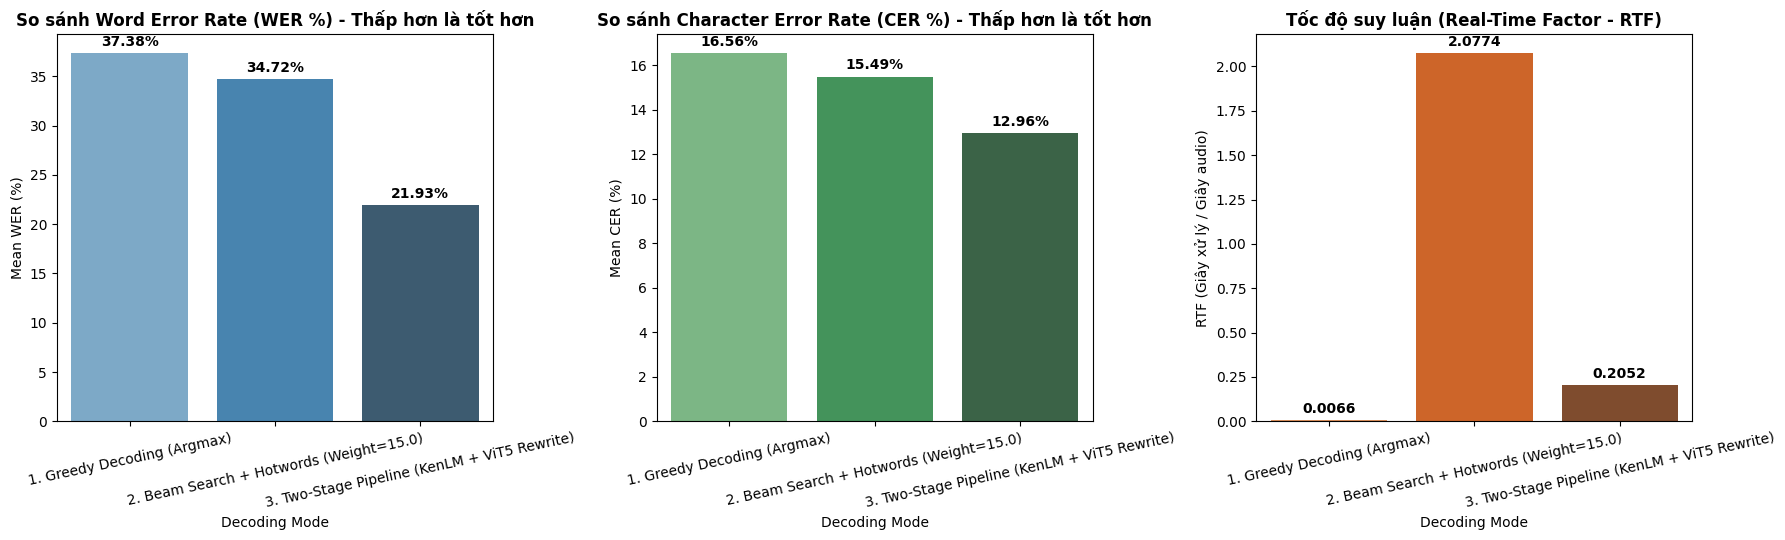

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# 1. Biểu đồ Mean WER
sns.barplot(data=summary_df, x="Decoding Mode", y="Mean WER (%)", ax=axes[0], palette="Blues_d")
axes[0].set_title("So sánh Word Error Rate (WER %) - Thấp hơn là tốt hơn", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Mean WER (%)")
axes[0].tick_params(axis='x', rotation=12)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight="bold")

# 2. Biểu đồ Mean CER
sns.barplot(data=summary_df, x="Decoding Mode", y="Mean CER (%)", ax=axes[1], palette="Greens_d")
axes[1].set_title("So sánh Character Error Rate (CER %) - Thấp hơn là tốt hơn", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Mean CER (%)")
axes[1].tick_params(axis='x', rotation=12)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight="bold")

# 3. Biểu đồ RTF
sns.barplot(data=summary_df, x="Decoding Mode", y="RTF (Speed)", ax=axes[2], palette="Oranges_d")
axes[2].set_title("Tốc độ suy luận (Real-Time Factor - RTF)", fontsize=12, fontweight="bold")
axes[2].set_ylabel("RTF (Giây xử lý / Giây audio)")
axes[2].tick_params(axis='x', rotation=12)
for p in axes[2].patches:
    axes[2].annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight="bold")

plt.tight_layout()
plt.show()

## 6. ĐÁNH GIÁ CHUYÊN SÂU ENTITY ACCURACY (ĐỘ CHÍNH XÁC THỰC THỂ TÊN THUỐC)

             ĐÁNH GIÁ ĐỘ CHÍNH XÁC THỰC THỂ TÊN THUỐC / BIỆT DƯỢC (ENTITY ACCURACY)


,Decoding Mode,Entity Recall (%),Entity Precision (%),Entity F1-Score (%),Drugs Matched / Total
0,1. Greedy Decoding (Argmax),0.00,0.00,0.00,0 / 92
1,2. Beam Search + Hotwords (Weight=15.0),8.70,33.33,13.79,8 / 92
2,3. Two-Stage Pipeline (KenLM + ViT5 Rewrite),9.78,42.86,15.93,9 / 92


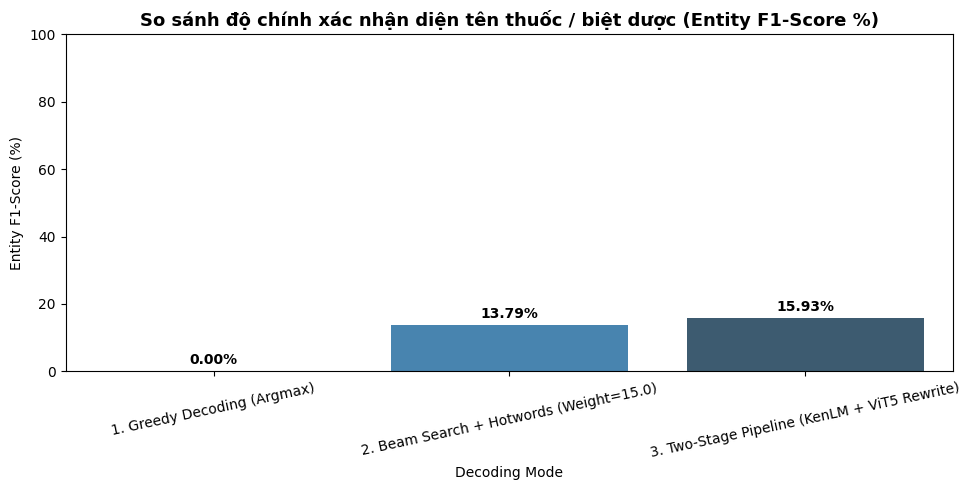

In [8]:
import re
print("=" * 95)
print("             ĐÁNH GIÁ ĐỘ CHÍNH XÁC THỰC THỂ TÊN THUỐC / BIỆT DƯỢC (ENTITY ACCURACY)")
print("=" * 95)
# Đảm bảo danh sách thuốc ở dạng chữ thường và từ dài >= 3 ký tự để tránh khớp từ thông dụng
drug_keywords_set = set(w.lower().strip() for w in HOTWORDS_MEDICAL if len(w.strip()) >= 3)
def extract_drug_entities(text):
  if not text or pd.isnull(text):
    return set()
  text_norm = re.sub(r'[\,\.\?\!\;\:\-\"\'\(\)]', ' ', str(text).lower())
  words = set(text_norm.split())
  found_drugs = words.intersection(drug_keywords_set)
  return found_drugs
def clean_hyp_for_entity(text):
  if not text or pd.isnull(text):
    return set()
  text_clean = re.sub(r'^fix_asr\s*:\s*', '', str(text), flags=re.IGNORECASE)
  text_norm = re.sub(r'[\,\.\?\!\;\:\-\"\'\(\)]', ' ', text_clean.lower())
  return set(text_norm.split())
def compute_entity_metrics(df, hyp_col):
  total_ref_entities = 0
  total_hyp_entities = 0
  total_matched_entities = 0
  for _, row in df.iterrows():
    ref_entities = extract_drug_entities(row['ref_text'])
    if not ref_entities:
      continue
    hyp_words = clean_hyp_for_entity(row[hyp_col])
    hyp_entities = hyp_words.intersection(drug_keywords_set)
    matched = ref_entities.intersection(hyp_words)
    total_ref_entities += len(ref_entities)
    total_hyp_entities += len(hyp_entities)
    total_matched_entities += len(matched)
  recall = (
      (total_matched_entities / total_ref_entities * 100)
      if total_ref_entities > 0
      else 0.0
  )
  precision = (
      (total_matched_entities / total_hyp_entities * 100)
      if total_hyp_entities > 0
      else 0.0
  )
  f1 = (
      (2 * precision * recall / (precision + recall))
      if (precision + recall) > 0
      else 0.0
  )
  return (
      round(recall, 2),
      round(precision, 2),
      round(f1, 2),
      total_ref_entities,
      total_matched_entities,
  )
rec_g, prec_g, f1_g, tot_ref, match_g = compute_entity_metrics(
    df_logs, 'trans_greedy'
)
rec_b, prec_b, f1_b, _, match_b = compute_entity_metrics(
    df_logs, 'trans_beam_hw'
)
rec_t, prec_t, f1_t, _, match_t = compute_entity_metrics(
    df_logs, 'trans_two_stage'
)
entity_summary_df = pd.DataFrame([
    {
        'Decoding Mode': '1. Greedy Decoding (Argmax)',
        'Entity Recall (%)': rec_g,
        'Entity Precision (%)': prec_g,
        'Entity F1-Score (%)': f1_g,
        'Drugs Matched / Total': f'{match_g} / {tot_ref}',
    },
    {
        'Decoding Mode': f'2. Beam Search + Hotwords (Weight={HOTWORD_WEIGHT})',
        'Entity Recall (%)': rec_b,
        'Entity Precision (%)': prec_b,
        'Entity F1-Score (%)': f1_b,
        'Drugs Matched / Total': f'{match_b} / {tot_ref}',
    },
    {
        'Decoding Mode': '3. Two-Stage Pipeline (KenLM + ViT5 Rewrite)',
        'Entity Recall (%)': rec_t,
        'Entity Precision (%)': prec_t,
        'Entity F1-Score (%)': f1_t,
        'Drugs Matched / Total': f'{match_t} / {tot_ref}',
    },
])
display(entity_summary_df)
# Trực quan hóa Biểu đồ Entity Accuracy
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=entity_summary_df,
    x='Decoding Mode',
    y='Entity F1-Score (%)',
    palette='Blues_d',
    ax=ax,
)
ax.set_title(
    'So sánh độ chính xác nhận diện tên thuốc / biệt dược (Entity F1-Score %)',
    fontsize=13,
    fontweight='bold',
)
ax.set_ylabel('Entity F1-Score (%)')
ax.tick_params(axis='x', rotation=12)
for p in ax.patches:
  ax.annotate(
      f'{p.get_height():.2f}%',
      (p.get_x() + p.get_width() / 2.0, p.get_height()),
      ha='center',
      va='center',
      xytext=(0, 8),
      textcoords='offset points',
      fontweight='bold',
  )
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

## 7. PHÂN TÍCH NGUYÊN NHÂN CER TĂNG & PHÂN TÍCH LỖI TRÊN CÁC VÍ DỤ CỤ THỂ

In [9]:
print("=" * 95)
print(
    "             KIỂM CHỨNG TOÁN HỌC: ĐO LƯỜNG CLEAN WER & CLEAN CER (LOẠI BỎ"
    " PREFIX & DẤU CÂU)"
)
print("=" * 95)
def compute_clean_metrics(df):
  clean_wers_greedy, clean_cers_greedy = [], []
  clean_wers_beam, clean_cers_beam = [], []
  clean_wers_vit5, clean_cers_vit5 = [], []
  for _, row in df.iterrows():
    ref_clean = re.sub(
        r'[\,\.\?\!\;\:\-\"\'\(\)]', ' ', str(row['ref_text']).lower()
    )
    ref_clean = re.sub(r'\s+', ' ', ref_clean).strip()
    greedy_clean = re.sub(
        r'[\,\.\?\!\;\:\-\"\'\(\)]', ' ', str(row['trans_greedy']).lower()
    )
    greedy_clean = re.sub(r'\s+', ' ', greedy_clean).strip()
    beam_clean = re.sub(
        r'[\,\.\?\!\;\:\-\"\'\(\)]', ' ', str(row['trans_beam_hw']).lower()
    )
    beam_clean = re.sub(r'\s+', ' ', beam_clean).strip()
    vit5_clean = re.sub(
        r'^fix_asr\s*:\s*',
        '',
        str(row['trans_two_stage']),
        flags=re.IGNORECASE,
    )
    vit5_clean = re.sub(r'[\,\.\?\!\;\:\-\"\'\(\)]', ' ', vit5_clean.lower())
    vit5_clean = re.sub(r'\s+', ' ', vit5_clean).strip()
    if not ref_clean:
      continue
    clean_wers_greedy.append(jiwer.wer(ref_clean, greedy_clean))
    clean_cers_greedy.append(jiwer.cer(ref_clean, greedy_clean))
    clean_wers_beam.append(jiwer.wer(ref_clean, beam_clean))
    clean_cers_beam.append(jiwer.cer(ref_clean, beam_clean))
    clean_wers_vit5.append(jiwer.wer(ref_clean, vit5_clean))
    clean_cers_vit5.append(jiwer.cer(ref_clean, vit5_clean))
  return (
      round(np.mean(clean_wers_greedy) * 100, 2),
      round(np.mean(clean_cers_greedy) * 100, 2),
      round(np.mean(clean_wers_beam) * 100, 2),
      round(np.mean(clean_cers_beam) * 100, 2),
      round(np.mean(clean_wers_vit5) * 100, 2),
      round(np.mean(clean_cers_vit5) * 100, 2),
  )
w_g_cl, c_g_cl, w_b_cl, c_b_cl, w_t_cl, c_t_cl = compute_clean_metrics(df_logs)
clean_comparison_df = pd.DataFrame([
    {
        'Decoding Mode': '1. Greedy Decoding (Argmax)',
        'Raw Mean WER (%)': summary_df.loc[0, 'Mean WER (%)'],
        'Clean Mean WER (%)': w_g_cl,
        'Raw Mean CER (%)': summary_df.loc[0, 'Mean CER (%)'],
        'Clean Mean CER (%)': c_g_cl,
    },
    {
        'Decoding Mode': f'2. Beam Search + Hotwords (Weight={HOTWORD_WEIGHT})',
        'Raw Mean WER (%)': summary_df.loc[1, 'Mean WER (%)'],
        'Clean Mean WER (%)': w_b_cl,
        'Raw Mean CER (%)': summary_df.loc[1, 'Mean CER (%)'],
        'Clean Mean CER (%)': c_b_cl,
    },
    {
        'Decoding Mode': '3. Two-Stage Pipeline (KenLM + ViT5 Rewrite)',
        'Raw Mean WER (%)': summary_df.loc[2, 'Mean WER (%)'],
        'Clean Mean WER (%)': w_t_cl,
        'Raw Mean CER (%)': summary_df.loc[2, 'Mean CER (%)'],
        'Clean Mean CER (%)': c_t_cl,
    },
])
display(clean_comparison_df)

             KIỂM CHỨNG TOÁN HỌC: ĐO LƯỜNG CLEAN WER & CLEAN CER (LOẠI BỎ PREFIX & DẤU CÂU)


,Decoding Mode,Raw Mean WER (%),Clean Mean WER (%),Raw Mean CER (%),Clean Mean CER (%)
0,1. Greedy Decoding (Argmax),37.38,32.07,16.56,15.22
1,2. Beam Search + Hotwords (Weight=15.0),34.72,29.45,15.49,14.15
2,3. Two-Stage Pipeline (KenLM + ViT5 Rewrite),21.93,20.84,12.96,12.59
